# **模块**: 基于PCA的多元统计过程监控
## **课程**: PCA工业案例研究
### *主题*:  降维

In [2]:
# 导入所需包
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
# 中文显示设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


np.set_printoptions(precision=3, suppress=True)

In [3]:
# ==================================================================================
#                        读取并探索数据集
# ==================================================================================

In [5]:
#%% fetch data
data = pd.read_excel('proc1a.xlsx',skiprows=1,usecols='C:AI')

print("\n 前几行数据：")
print(data.head())


 前几行数据：
   x1in  x2in  x3in  x4in  x5in  x6in  x7in    y1    y2    y3  ...  xgnx  \
0  0.47 -1.66 -0.19  1.94  0.07 -4.54 -0.09 -1.13  0.62  0.24  ... -0.13   
1  0.05 -0.83  0.04  0.75  0.25 -0.02 -0.60 -0.89  0.68  0.14  ... -0.17   
2 -0.58 -0.21 -0.08  0.89  0.34  0.12 -0.86 -0.81  0.77  0.12  ...  0.07   
3 -0.90  0.11  0.16  1.43  0.45  0.13 -0.41 -0.70  0.69  0.21  ...  0.17   
4 -0.78 -0.33 -0.34  1.51  0.50 -0.01 -0.31 -0.38  0.91  0.07  ...  0.14   

   xhnx  xinx  xjnx  xknx  xlnx  xmen  xnen  xoen  xpen  
0 -0.12  0.24  0.22 -0.01  0.27 -0.21  0.38  0.09 -0.11  
1 -0.11  0.22  0.05 -0.08  0.18 -0.33  0.34 -0.04 -0.33  
2 -0.17  0.20 -0.02 -0.13  0.31 -0.41  0.22  0.04 -0.01  
3 -0.01  0.29  0.07  0.01  0.30 -0.49  0.30 -0.22  0.00  
4 -0.05  0.26  0.06 -0.04  0.33 -0.58  0.23 -0.27 -0.28  

[5 rows x 33 columns]


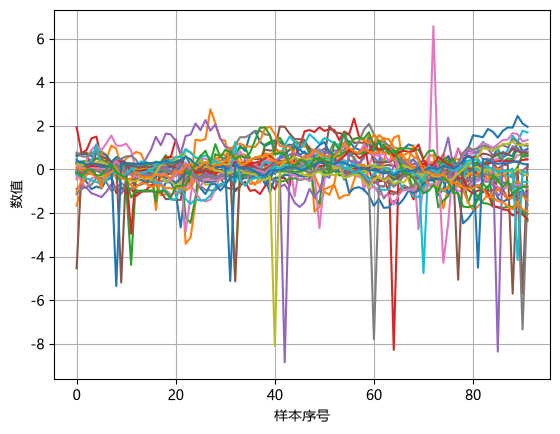

In [6]:
#%% visualize complete data
plt.figure()
plt.plot(data)
plt.ylabel('数值'), plt.xlabel('样本序号')
plt.grid()

In [7]:
# ==================================================================================
#                        拟合PCA模型 
# ==================================================================================

In [8]:
# 划分训练数据
data_train = data.iloc[0:69,]
           
# 缩放数据
scaler = StandardScaler()
data_train_normal = scaler.fit_transform(data_train)
           
# 拟合PCA（默认保留所有主成分）
pca = PCA()
scores_train = pca.fit_transform(data_train_normal)

print('scores_train 矩阵形状：', scores_train.shape)

scores_train 矩阵形状： (69, 33)


##### 我们尚未完成降维。PCA只是在scores_train中提供了不相关的数据集。为验证这一点，可计算score_train各列之间相关系数的热力图。 

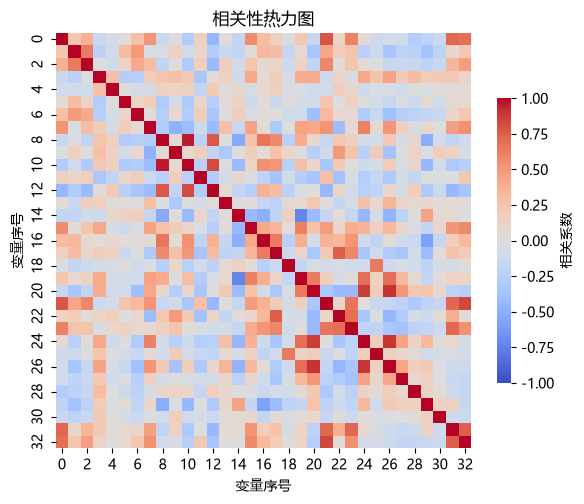

In [10]:
# 原始缩放变量间相关系数热力图
import seaborn as sns

# 计算相关系数矩阵
correlation_matrix_originalVariables = np.corrcoef(data_train_normal.T)

# 创建热力图
plt.figure(figsize=(6, 6))
sns.heatmap(correlation_matrix_originalVariables, 
            cmap='coolwarm',  # Color scheme (red for positive, blue for negative correlations)
            vmin=-1,  # Minimum correlation value
            vmax=1,   # Maximum correlation value
            center=0, # Center the colormap at 0
            square=True, # Make the plot square-shaped
            cbar_kws={
                'shrink': 0.5,  # height
                'label': '相关系数',  # add label
            }) # Format correlation values to 2 decimal places

plt.xlabel('变量序号'), plt.ylabel('变量序号')
plt.title('相关性热力图')
plt.tight_layout()
plt.show()

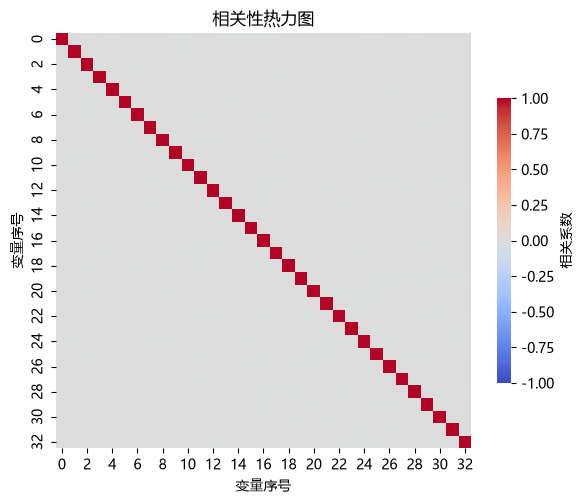

In [11]:
# 变换后变量间相关系数热力图
correlation_matrix_Scores = np.corrcoef(scores_train.T)

# 创建热力图
plt.figure(figsize=(6, 6))
sns.heatmap(correlation_matrix_Scores, 
            cmap='coolwarm',  # Color scheme (red for positive, blue for negative correlations)
            vmin=-1,  # Minimum correlation value
            vmax=1,   # Maximum correlation value
            center=0, # Center the colormap at 0
            square=True, # Make the plot square-shaped
            cbar_kws={
                'shrink': 0.5,  # height
                'label': '相关系数',  # add label
            }) # Format correlation values to 2 decimal places

plt.xlabel('变量序号'), plt.ylabel('变量序号')
plt.title('相关性热力图')
plt.tight_layout()
plt.show()

##### 现在来看各主成分捕获的方差

In [12]:
# 获取各主成分得分的特征值或方差
variances_captured = pca.explained_variance_
print('主成分得分方差：', variances_captured)

主成分得分方差： [6.423 5.529 5.218 2.576 1.949 1.655 1.424 1.275 1.03  1.005 0.865 0.839
 0.667 0.618 0.568 0.318 0.259 0.235 0.207 0.172 0.16  0.106 0.087 0.067
 0.051 0.044 0.038 0.032 0.023 0.021 0.015 0.008 0.   ]


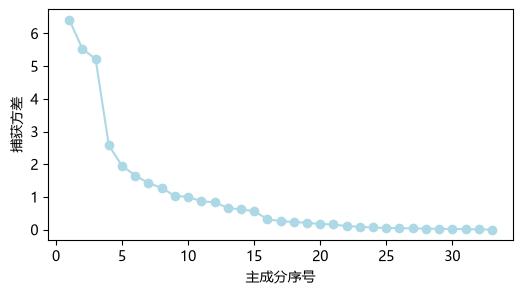

In [13]:
# 可视化方差 
plt.figure(figsize=(6,3))
plt.plot(range(1, len(variances_captured) + 1), variances_captured, color='lightblue', marker='o')
plt.xlabel('主成分序号'), plt.ylabel('捕获方差')
plt.show()

In [14]:
# ==================================================================================
#                   通过CPV图确定保留的主成分数量
# ==================================================================================

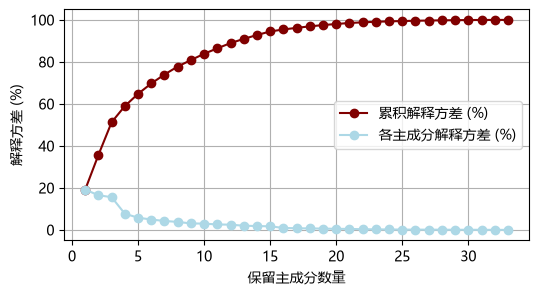

In [15]:
explained_variance = 100*pca.explained_variance_ratio_ # in percentage
cum_explained_variance = np.cumsum(explained_variance) # cumulative % variance explained

plt.figure(figsize=(6,3))
plt.plot(range(1, len(variances_captured) + 1), cum_explained_variance, color='maroon', marker='o', label = '累积解释方差 (%)')
plt.plot(range(1, len(variances_captured) + 1), explained_variance, color='lightblue', marker='o', label = '各主成分解释方差 (%)')
plt.ylabel('解释方差 (%)')
plt.xlabel('保留主成分数量')
plt.legend()
plt.grid()
plt.show()

In [16]:
# 确定保留的主成分数量
n_comp = np.argmax(cum_explained_variance >= 90) + 1
print('累积解释至少 90% 方差的主成分数：', n_comp)

累积解释至少 90% 方差的主成分数： 13


In [17]:
# ==================================================================================
#                   执行降维
# ==================================================================================

In [18]:
# 计算主成分空间中的降维数据
scores_train_reduced = scores_train[:,0:n_comp]
print('得分矩阵形状：', scores_train_reduced.shape)

得分矩阵形状： (69, 13)


In [19]:
# ==================================================================================
#              用减少的主成分数量重新拟合PCA
# ==================================================================================

In [20]:
# 拟合PCA（仅保留n_comp个主成分）
pca = PCA(n_components=n_comp)  # retain only n_comp PCs
scores_train_reduced = pca.fit_transform(data_train_normal)

print('得分矩阵形状：', scores_train_reduced.shape)

得分矩阵形状： (69, 13)


##### 使用降维后的得分矩阵重构数据，并直观确认仅丢失了少量信息。

In [21]:
# ==================================================================================
#                               重构
# ==================================================================================

In [22]:
data_train_normal_reconstruct = pca.inverse_transform(scores_train_reduced)

print('重构 X（归一化）矩阵形状：', data_train_normal_reconstruct.shape)

重构 X（归一化）矩阵形状： (69, 33)


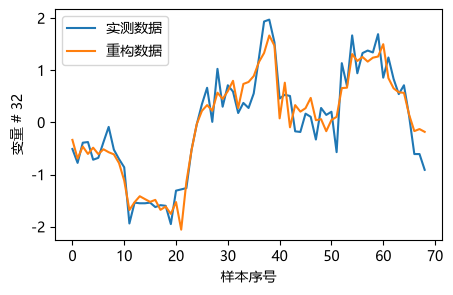

In [23]:
# 绘制原始与重构变量对比图
var = 32
plt.figure(figsize=(5,3))
plt.plot(data_train_normal[:,var],label = '实测数据')
plt.plot(data_train_normal_reconstruct[:,var],label = '重构数据')
plt.ylabel('变量 # '+ str(var))
plt.xlabel('样本序号')
plt.legend()
plt.show()